## 1 - Exploración inicial
Antes de aplicar un algoritmo de clustering, analice la estructura del conjunto de datos customer_data.csv y analice las variables Age e Income mediante estadísticos descriptivos. Represente gráficamente la relación entre edad e ingreso.

¿Se observan grupos claramente separados a simple vista en el plano edad-ingreso?

               Age         Income
count  2000.000000    2000.000000
mean     35.909000  120954.419000
std      11.719402   38108.824679
min      18.000000   35832.000000
25%      27.000000   97663.250000
50%      33.000000  115548.500000
75%      42.000000  138072.250000
max      76.000000  309364.000000


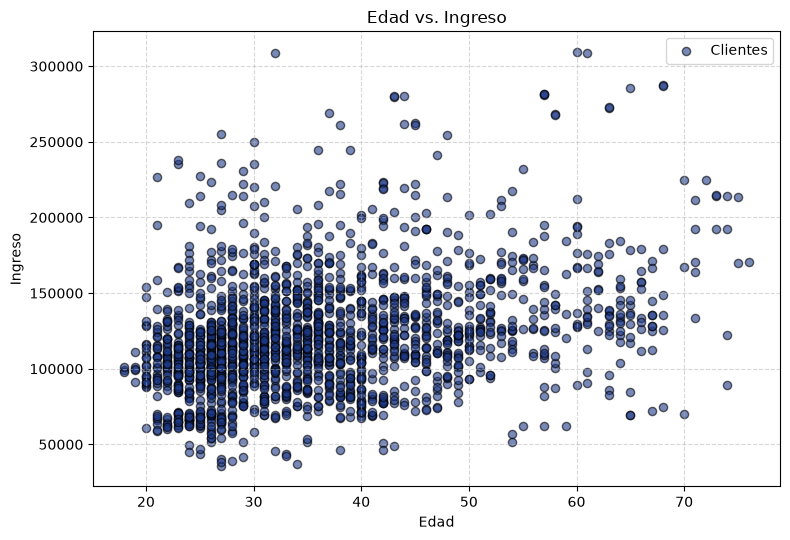

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

clientes_df = pd.read_csv("./data/customer_data.csv")

print(clientes_df[['Age', 'Income']].describe())

plt.figure(figsize = (8, 5.5))

plt.scatter(
    clientes_df['Age'],
    clientes_df['Income'],
    color = '#1E3A8A',
    alpha=0.6,
    edgecolor='k',
    s=35, 
    label = 'Clientes'
)


plt.title('Edad vs. Ingreso')
plt.xlabel('Edad')
plt.ylabel('Ingreso')
plt.grid(True, linestyle = '--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

No pueden observarse grupos claramente delimitados. Si bien no todos los datos están agrupados en un solo espacio, no existen vacíos significativos que delimiten dos grupos. Sin embargo hay una gran concentración notable en la esquina inferior izquierda y una mayor dispersión en la parte superior derecha.

### 2. Selección de características y escalado

Para construir los clusters se utilizarán únicamente:

$$
X = [\text{Age},\text{Income}]
$$

Las demás variables se reservarán para describir los segmentos una vez obtenidos.

### 3. Selección del número de clusters con K-Means

No se conoce de antemano cuántos grupos existen en los datos.

1. Ajuste K-Means para valores de $K$ entre 1 y 10.
2. Registre la inercia o WCSS para cada valor de $K$.
3. Para $K \geq 2$, calcule además el coeficiente de silueta promedio.
4. Represente:
   - WCSS en función de $K$.
   - coeficiente de silueta promedio en función de $K$.
5. Identifique los valores de $K$ que considera más razonables y justifique.

RESULTADOS
 K   Inercia Silueta Promedio
 1 4000.0000              NaN
 2 2260.2037           0.4424
 3 1647.5540           0.4394
 4 1281.1447           0.3503
 5 1024.2394           0.3648
 6  865.9056           0.3555
 7  751.3056           0.3556
 8  665.0295           0.3561
 9  582.9290           0.3617
10  511.2343           0.3674


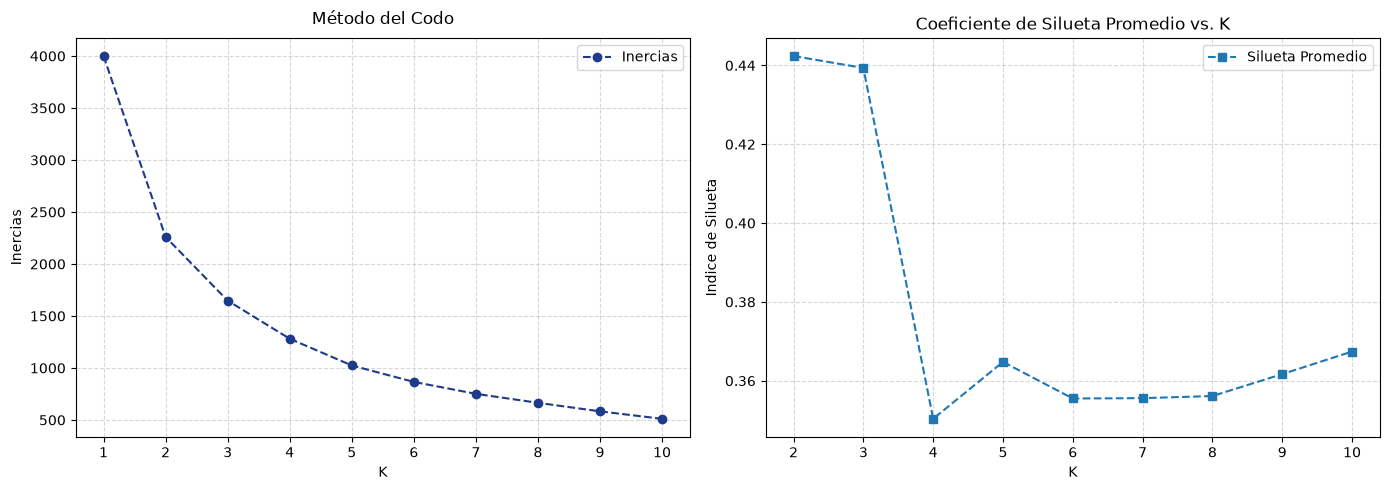

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

clientes_df = pd.read_csv('./data/customer_data.csv')

columnas = clientes_df[['Age', 'Income']]

#Escalamos
scaler = StandardScaler()
columnas_escaladas = scaler.fit_transform(columnas)

k_rango = range(1,11)
inercias = []
coeficientes_silueta = []

for k in k_rango:
    kmeans =  KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(columnas_escaladas)

    inercias.append(kmeans.inertia_)

    if k>=2:
        coeficiente = silhouette_score(columnas_escaladas, kmeans.labels_)
        coeficientes_silueta.append(coeficiente)
    else:
        coeficientes_silueta.append(np.nan)
df_resultados = pd.DataFrame({
    'K': k_rango,
    'Inercia': inercias,
    'Silueta Promedio': coeficientes_silueta
})

print("RESULTADOS")
print(df_resultados.to_string(index = False, formatters={
    'Inercia': '{:.4f}'.format,
    'Silueta Promedio': lambda x: '{:.4f}'.format(x) if not np.isnan(x) else 'N/A'
}))



fig, axs = plt.subplots(1, 2, figsize=(14, 5))
#Grafica de Codo
axs[0].plot(k_rango, inercias, marker='o', linestyle = '--', color='#1E3A8A', label='Inercias')
axs[0].set_title('Método del Codo', pad = 10)
axs[0].set_xlabel('K')
axs[0].set_ylabel('Inercias')
axs[0].set_xticks(k_rango)
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

#Coeficiente de Silueta vs. K
axs[1].plot(list(range(2,11)), coeficientes_silueta[1:], marker='s', linestyle='--', label='Silueta Promedio')
axs[1].set_title('Coeficiente de Silueta Promedio vs. K')
axs[1].set_xlabel('K')
axs[1].set_ylabel('Indice de Silueta')
axs[1].set_xticks(range(2,11))
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

plt.tight_layout()
plt.show()

Considerando los datos observados, se infiere que los mejores valores para K son:
* K = 2: tiene el coeficiente de silueta proedio más alto, indicando que es el valor que presenta mejor coehsión interna y mejor separación entre los grupos.
* K = 3: mantiene un coeficiente de silueta promedio alto (0,4394) y presenta un punto de inflexión en la gráfica de Inercia vs. K, demostrando que allí la curva empieza a aplanarse y la reducción de inercia empieza a ser marginal en dicho punto

## 4. Análisis de los diagramas de silueta
El coeficiente promedio resume el resultado en un único número, pero no permite observar cómo se comportan las observaciones dentro de cada cluster.

Construya diagramas de silueta para  K=2 ,  K=3 ,  K=4  y  k=5 .

Interprételo de acuerdo a los criterios vistos en la notebook de práctica.

Utilice esta información para complementar la elección de  K .

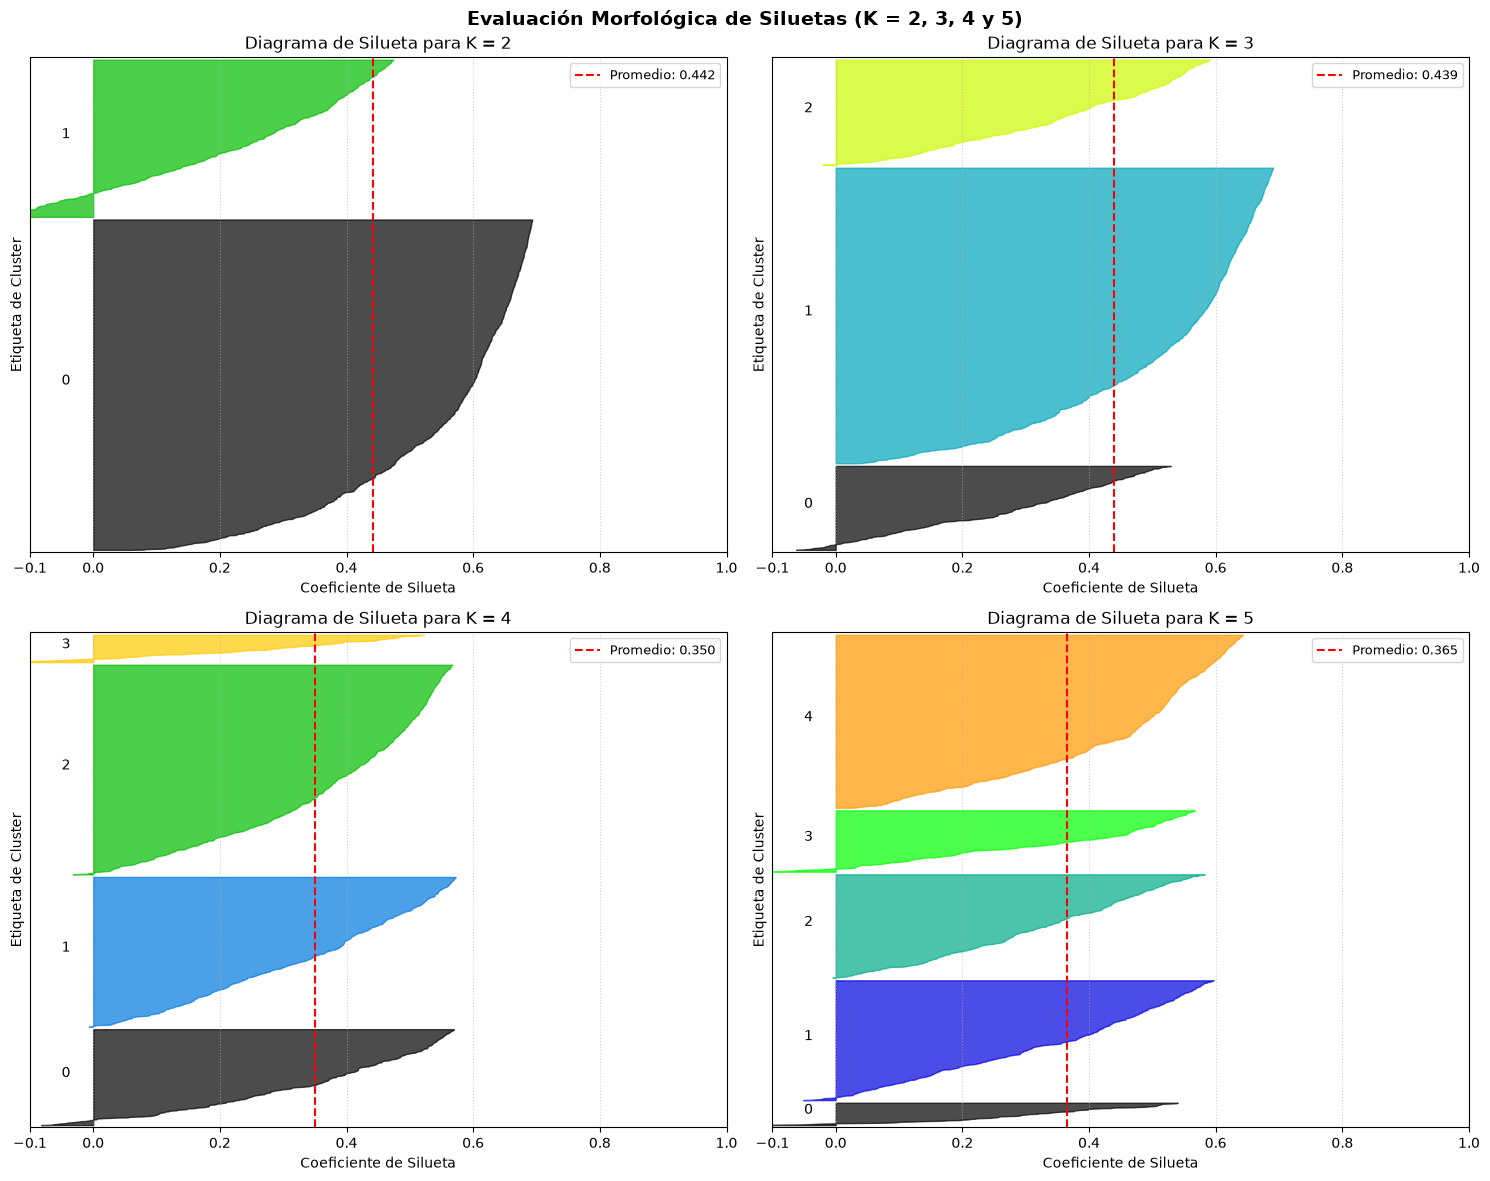

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

clientes_df = pd.read_csv('./data/customer_data.csv')
columnas = clientes_df[['Age', 'Income']]

scaler = StandardScaler()
columnas_escaladas = scaler.fit_transform(columnas)

range_n_clusters = [2, 3, 4, 5]

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.ravel()

for idx, n_clusters in enumerate(range_n_clusters):
    ax = axs[idx]
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(columnas_escaladas) + (n_clusters + 1) * 10])
    
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(columnas_escaladas)
    
    silhouette_avg = silhouette_score(columnas_escaladas, cluster_labels)
    sample_silhouette_values = silhouette_samples(columnas_escaladas, cluster_labels)
    
    y_lower = 10 
    for i in range(n_clusters): 
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f"Diagrama de Silueta para K = {n_clusters}")
    ax.set_xlabel("Coeficiente de Silueta")
    ax.set_ylabel("Etiqueta de Cluster")

    ax.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=1.5,
               label=f"Promedio: {silhouette_avg:.3f}")

    ax.set_yticks([]) 
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc="upper right", fontsize=9)

plt.suptitle("Evaluación Morfológica de Siluetas (K = 2, 3, 4 y 5)", 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


        



Complementando las conclusiones a las que se llegó anteriormente, se puede observar que:
- k=2 tiene un desequilibrio notable en el volumen de los grupos siendo el 0 quien agrupa la gran mayoria de los datos. En el cluster 1 se observan coeficientes negativos.
- k=3 presenta una estructura más estable y consistente, el cluster 1 es más voluminosos pero se logra que se supere el coeficiente promedio. 
- k= 4 y 5 tienen una menor calidad y el promedio general cae y tiene importantes desequilibrios entre grupos. 


## 5. Segmentación final con K-Means
Ajuste un modelo K-Means utilizando el valor de K seleccionado.

Obtenga la etiqueta asignada a cada cliente.
Represente los clusters utilizando las variables originales Age e Income.
Calcule los centroides y represéntelos en el gráfico.
Interprete qué representan los grupos obtenidos.
Recuerde que los números asignados a los clusters son identificadores arbitrarios: Cluster 0 no implica que ese grupo sea menor o más importante que Cluster 1.

Agrupamiento
 Cluster  Tamano Edad_Promedio Ingreso_Promedio Masculino_Ratio Casado_Ratio  Educacion_Mediana  Ocupacion_Mediana  Ciudad_Mediana
       0     347    35.89 años      $175,604.58           74.6%        39.5%                1.0                2.0             1.0
       1    1218    29.71 años      $101,742.81           45.1%        56.7%                1.0                1.0             0.0
       2     435    53.28 años      $131,152.44           63.9%        37.9%                2.0                1.0             1.0


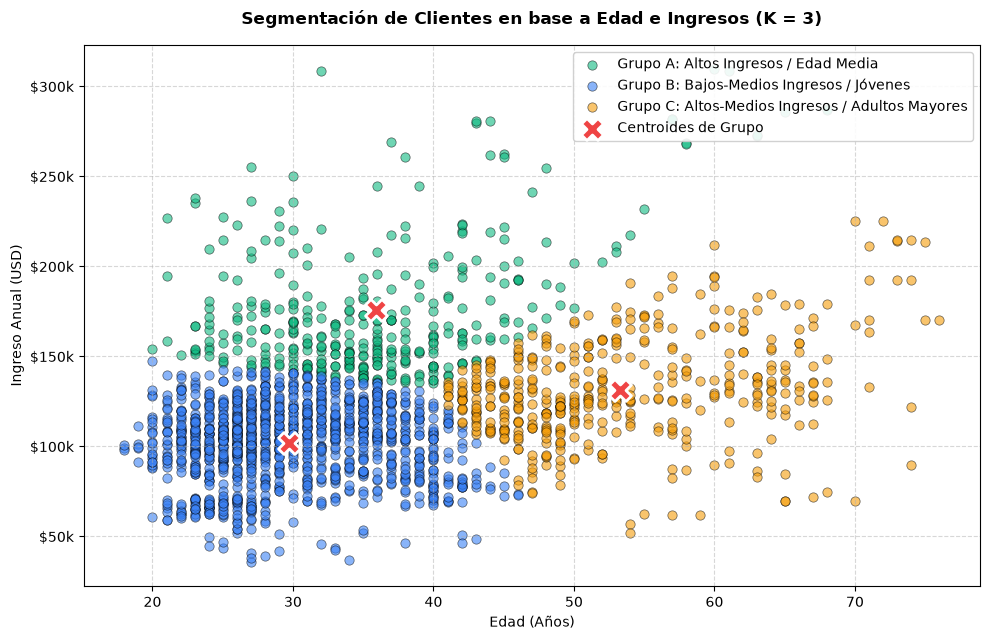

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

clientes_df = pd.read_csv('./data/customer_data.csv')
columnas = clientes_df[['Age', 'Income']]

scaler = StandardScaler()
columnas_escaladas = scaler.fit_transform(columnas)

kmeans = KMeans(n_clusters = 3, random_state = 42, n_init = 10)
clientes_df['Cluster'] = kmeans.fit_predict(columnas_escaladas)

centroides_escalados = kmeans.cluster_centers_
centroides_reales = scaler.inverse_transform(centroides_escalados)


# Agrupamos por cluster y calculamos métricas clave para perfilar
perfiles = clientes_df.groupby('Cluster').agg(
    Tamano=('ID', 'count'),
    Edad_Promedio=('Age', 'mean'),
    Ingreso_Promedio=('Income', 'mean'),
    Masculino_Ratio=('Sex', lambda x: (x == 0).mean()), 
    Casado_Ratio=('Marital status', 'mean'),           
    Educacion_Mediana=('Education', 'median'),          
    Ocupacion_Mediana=('Occupation', 'median'),         
    Ciudad_Mediana=('Settlement size', 'median')        
).reset_index()

print("Agrupamiento")
print(perfiles.to_string(index=False, formatters={
    'Edad_Promedio': '{:.2f} años'.format,
    'Ingreso_Promedio': '${:,.2f}'.format,
    'Masculino_Ratio': '{:.1%}'.format,
    'Casado_Ratio': '{:.1%}'.format
}))


plt.figure(figsize=(10, 6.5))
colores = {0: '#10B981', 1: '#3B82F6', 2: '#F59E0B'}
nombres_grupos = {
    0: 'Grupo A: Altos Ingresos / Edad Media',
    1: 'Grupo B: Bajos-Medios Ingresos / Jóvenes',
    2: 'Grupo C: Altos-Medios Ingresos / Adultos Mayores'
}

for c_id in sorted(clientes_df['Cluster'].unique()):
    sub_df = clientes_df[clientes_df['Cluster'] == c_id]
    plt.scatter(
        sub_df['Age'], 
        sub_df['Income'], 
        color=colores[c_id],
        alpha=0.6, 
        edgecolors='k', 
        linewidths=0.5,
        s=45,
        label=nombres_grupos[c_id]
    )

plt.scatter(
    centroides_reales[:, 0], 
    centroides_reales[:, 1], 
    color='#EF4444', 
    marker='X', 
    s=250, 
    edgecolors='white', 
    linewidths=2,
    zorder=10,
    label='Centroides de Grupo'
)

plt.title('Segmentación de Clientes en base a Edad e Ingresos (K = 3)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Edad (Años)', fontsize=10)
plt.ylabel('Ingreso Anual (USD)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

import matplotlib.ticker as ticker
formatter = ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k')
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

## 6. Caracterización de los segmentos
Agregue las etiquetas de K-Means al conjunto de datos original y describa cada cluster utilizando las características disponibles.

Para cada grupo analice:

cantidad de clientes;
edad media y mediana;
ingreso medio y mediano;
distribución por género;
estado civil;
nivel educativo;
ocupación;
tamaño de la ciudad de residencia.
A partir de estos resultados, elabore una descripción breve de cada segmento. Puede utilizar herramientas de pandas para esta tarea.

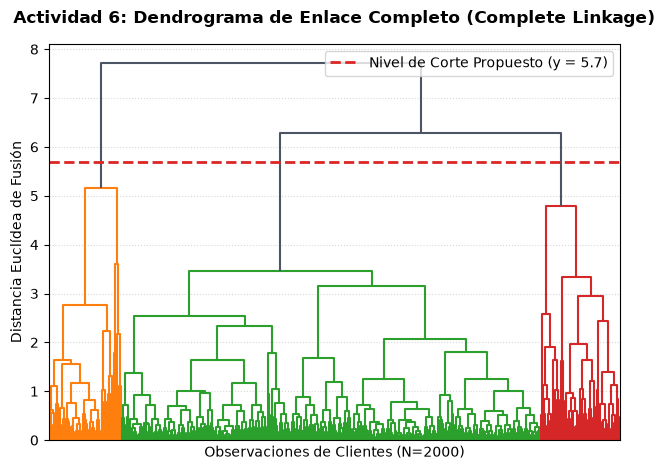

COMPARATIVA
Coeficiente de Silueta - K-Means: 0.4394
Coeficiente de Silueta - Jerárquico: 0.4021


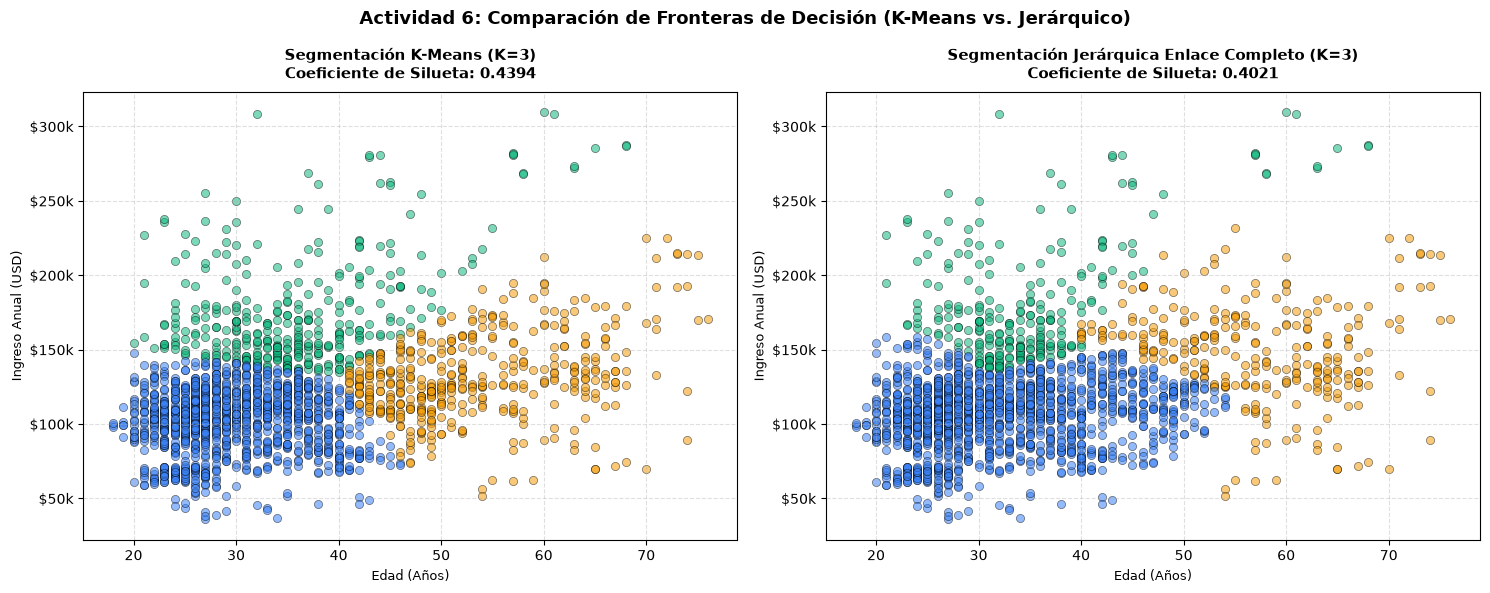

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

clientes_df = pd.read_csv('./data/customer_data.csv')
columnas = clientes_df[['Age', 'Income']]

scaler = StandardScaler()
columnas_escaladas = scaler.fit_transform(columnas)

Z = linkage(columnas_escaladas, method='complete', metric='euclidean')
dendrogram(
    Z,
    no_labels=True,
    color_threshold=5.5,  # Colorea las ramas según el nivel de corte propuesto
    above_threshold_color='#4B5563'
)

plt.axhline(y=5.7, color='#DC2626', linestyle='--', linewidth=2, label='Nivel de Corte Propuesto (y = 5.7)')

plt.title('Actividad 6: Dendrograma de Enlace Completo (Complete Linkage)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Observaciones de Clientes (N=2000)', fontsize=10)
plt.ylabel('Distancia Euclídea de Fusión', fontsize=10)
plt.grid(True, which='both', axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(columnas_escaladas)
sil_km = silhouette_score(columnas_escaladas, labels_km)

ac = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='complete')
labels_ac = ac.fit_predict(columnas_escaladas)
sil_ac = silhouette_score(columnas_escaladas, labels_ac)

print("COMPARATIVA")
print(f"Coeficiente de Silueta - K-Means: {sil_km:.4f}")
print(f"Coeficiente de Silueta - Jerárquico: {sil_ac:.4f}")


fig, axs = plt.subplots(1, 2, figsize=(15, 6))
colores_km = {0: '#10B981', 1: '#3B82F6', 2: '#F59E0B'}
colores_ac = {0: '#10B981', 1: '#F59E0B', 2: '#3B82F6'} 

for c_id in np.unique(labels_km):
    sub_columnas = columnas[labels_km == c_id]
    axs[0].scatter(
        sub_columnas['Age'], sub_columnas['Income'],
        color=colores_km[c_id], alpha=0.55, edgecolors='k', linewidths=0.5, s=35
    )
axs[0].set_title(f'Segmentación K-Means (K=3)\nCoeficiente de Silueta: {sil_km:.4f}', fontsize=11, fontweight='bold', pad=10)
axs[0].set_xlabel('Edad (Años)', fontsize=9)
axs[0].set_ylabel('Ingreso Anual (USD)', fontsize=9)
axs[0].grid(True, linestyle='--', alpha=0.4)

for c_id in np.unique(labels_ac):
    sub_columnas = columnas[labels_ac == c_id]
    axs[1].scatter(
        sub_columnas['Age'], sub_columnas['Income'],
        color=colores_ac[c_id], alpha=0.55, edgecolors='k', linewidths=0.5, s=35
    )
axs[1].set_title(f'Segmentación Jerárquica Enlace Completo (K=3)\nCoeficiente de Silueta: {sil_ac:.4f}', fontsize=11, fontweight='bold', pad=10)
axs[1].set_xlabel('Edad (Años)', fontsize=9)
axs[1].set_ylabel('Ingreso Anual (USD)', fontsize=9)
axs[1].grid(True, linestyle='--', alpha=0.4)



import matplotlib.ticker as ticker
for ax in axs:
    formatter = ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k')
    ax.yaxis.set_major_formatter(formatter)

plt.suptitle('Actividad 6: Comparación de Fronteras de Decisión (K-Means vs. Jerárquico)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

plt.show()

Se elaboran los siguientes perfiles comerciales de cada cluster de clientes:
- 0: Es el segmento con mayor poder adquisitivo, lo integra mayorment4e hombres jóvenes-adultos (74.6% con edad media de 36 años) residentes de ciudades grandes/medianas con un ingreso anual promedio de $175,604.58, ocupaciones como puestos directivos, gerenciales o de ealta especialización. Tienen tasas de matrimonio regulares (39.5%)
- 1: Cluster mayoritario, conformado por ambos sexos (ligera mayoria de mujeres 54,9%) y edad media de 29,7 años. Ingreso promedio de $101,742.81 con la tasa más alta de casados (56.7%), educación secundaria y trabajan en puestos operativos o calificación media, viven en ciudades pequeñas o áreas ruarles. 
- 2: Segmento con mayor esttabilidad temporal. Adultos mayores y jubilados (edad media 53.3 años) con predominancia masculina (63.9%)
Tienen un ingreso medio-alto muy estable ($131,152.44) con alto nivel educativo. Viven en ciudades de tamaño mediano con baja tasa de matrimonio (37.9)